# Books to Scrape – Data Collection & Analysis

# Web Scraping Script

**Objective:** A reproducible Python script or notebook that extracts data from a chosen website or API.

**Website:** Books to Scrape

Steps followed:

1. Imported the required Python libraries.
2. Sent requests to the website using requests.
3. Used BeautifulSoup to read the HTML content.
4. Scraped the book title, price, and rating.
5. Collected data from 50 pages.
6. Stored the scraped data in a Pandas DataFrame.
7. A total of 1000 book records were collected.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

books = []

for page in range(1, 51):
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    for book in soup.select("article.product_pod"):
        title = book.h3.a["title"]
        price = book.select_one(".price_color").text.strip()
        rating = book.p.get("class")[1]

        books.append({
            "title": title,
            "price": price,
            "rating": rating
        })

books_df = pd.DataFrame(books)

print("Total records:", len(books_df))
print("\nFirst 5 records:")
display(books_df.head())

Total records: 1000

First 5 records:


,title,price,rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


**Output**:
The scraping was completed successfully and the dataset contains 1000 records with 3 columns: title, price, and rating.

#Data Cleaning & Preprocessing #


In [2]:
# Check missing values
print("Missing values before cleaning:")
print(books_df.isnull().sum())

# Remove duplicate records
books_df = books_df.drop_duplicates()

# Clean price column
books_df["price"] = books_df["price"].astype(str).str.extract(r"(\d+(?:\.\d+)?)")[0]
books_df["price"] = pd.to_numeric(books_df["price"], errors="coerce")

# Convert rating words into numbers
# Convert rating text into numbers cleanly
books_df["rating"] = books_df["rating"].astype(str).str.replace("star-rating ", "", case=False).str.strip()

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

books_df["rating_num"] = books_df["rating"].map(rating_map)

print("\nMissing values after cleaning:")
print(books_df.isnull().sum())

print("\nDataset shape after cleaning:")
print(books_df.shape)

display(books_df.head())

Missing values before cleaning:
title     0
price     0
rating    0
dtype: int64

Missing values after cleaning:
title         0
price         0
rating        0
rating_num    0
dtype: int64

Dataset shape after cleaning:
(1000, 4)


,title,price,rating,rating_num
0,A Light in the Attic,51.77,Three,3
1,Tipping the Velvet,53.74,One,1
2,Soumission,50.10,One,1
3,Sharp Objects,47.82,Four,4
4,Sapiens: A Brief History of Humankind,54.23,Five,5


In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

books = []

for page in range(1, 51):
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    for book in soup.select("article.product_pod"):
        title = book.h3.a["title"]
        price = book.select_one(".price_color").text.strip()
        rating = book.p["class"][1]

        books.append({
            "title": title,
            "price": price,
            "rating": rating
        })

books_df = pd.DataFrame(books)

print("Total records:", len(books_df))
display(books_df.head())

Total records: 1000


,title,price,rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


There are no missing values in the dataset. So, no rows were removed or filled because of missing data.

In [4]:
# Recreate the dataframe from the original scraped data
books_df = pd.DataFrame(books).copy()

# Clean price safely
books_df["price"] = (
    books_df["price"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
)

books_df["price"] = pd.to_numeric(
    books_df["price"],
    errors="coerce"
)

print("Price after cleaning:")
display(books_df[["title", "price"]].head())

print("\nMissing values:")
print(books_df.isnull().sum())

print("\nDataset shape:", books_df.shape)

Price after cleaning:


,title,price
0,A Light in the Attic,51.77
1,Tipping the Velvet,53.74
2,Soumission,50.10
3,Sharp Objects,47.82
4,Sapiens: A Brief History of Humankind,54.23



Missing values:
title     0
price     0
rating    0
dtype: int64

Dataset shape: (1000, 3)


In [5]:
# Price and Rating Analysis

print("PRICE ANALYSIS")
print("-" * 40)

print("Average price:", round(books_df["price"].mean(), 2))
print("Minimum price:", round(books_df["price"].min(), 2))
print("Maximum price:", round(books_df["price"].max(), 2))

print("\nRATING DISTRIBUTION")
print("-" * 40)

rating_counts = books_df["rating"].value_counts().sort_index()
print(rating_counts)

print("\nAVERAGE PRICE BY RATING")
print("-" * 40)

avg_price_rating = books_df.groupby("rating")["price"].mean().round(2)
print(avg_price_rating)

# Find most common rating
most_common_rating = rating_counts.idxmax()
most_common_count = rating_counts.max()

print("\nINSIGHT")
print("-" * 40)

print(
    f"The average book price is £{books_df['price'].mean():.2f}, "
    f"with prices ranging from £{books_df['price'].min():.2f} "
    f"to £{books_df['price'].max():.2f}."
)

print(
    f"The most common rating is {most_common_rating} stars, "
    f"with {most_common_count} books having this rating."
)

print("\nRECOMMENDATION")
print("-" * 40)

print(
    "Books can be shown using both rating and price so customers "
    "can easily compare highly rated and affordable options."
)

PRICE ANALYSIS
----------------------------------------
Average price: 35.07
Minimum price: 10.0
Maximum price: 59.99

RATING DISTRIBUTION
----------------------------------------
rating
Five     196
Four     179
One      226
Three    203
Two      196
Name: count, dtype: int64

AVERAGE PRICE BY RATING
----------------------------------------
rating
Five     35.37
Four     36.09
One      34.56
Three    34.69
Two      34.81
Name: price, dtype: float64

INSIGHT
----------------------------------------
The average book price is £35.07, with prices ranging from £10.00 to £59.99.
The most common rating is One stars, with 226 books having this rating.

RECOMMENDATION
----------------------------------------
Books can be shown using both rating and price so customers can easily compare highly rated and affordable options.


### Feature Engineering

New features were created from the existing book data to make the dataset more useful for analysis:
- title_length: Number of characters in the book title.
- price_category: Books grouped into Low, Medium, and High price ranges.

In [6]:
# Feature Engineering

# Feature 1: Length of book title
books_df["title_length"] = books_df["title"].str.len()

# Feature 2: Price category
books_df["price_category"] = pd.cut(
    books_df["price"],
    bins=[0, 20, 40, 60],
    labels=["Low", "Medium", "High"]
)

print("Feature engineering completed.")
print("\nNew features:")
display(books_df[["title", "price", "title_length", "price_category"]].head())

print("\nUpdated dataset shape:")
print(books_df.shape)

Feature engineering completed.

New features:


,title,price,title_length,price_category
0,A Light in the Attic,51.77,20,High
1,Tipping the Velvet,53.74,18,High
2,Soumission,50.10,10,High
3,Sharp Objects,47.82,13,High
4,Sapiens: A Brief History of Humankind,54.23,37,High



Updated dataset shape:
(1000, 5)


In [7]:
# Final data cleaning validation

print("Duplicate records:", books_df.duplicated().sum())
print("\nMissing values:")
print(books_df.isnull().sum())

print("\nData types:")
print(books_df.dtypes)

print("\nFinal dataset shape:")
print(books_df.shape)

Duplicate records: 0

Missing values:
title             0
price             0
rating            0
title_length      0
price_category    0
dtype: int64

Data types:
title               object
price              float64
rating              object
title_length         int64
price_category    category
dtype: object

Final dataset shape:
(1000, 5)


In [8]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

books_df["rating"] = books_df["rating"].map(rating_map)

print("Rating data type:", books_df["rating"].dtype)
print("Missing ratings:", books_df["rating"].isnull().sum())

Rating data type: int64
Missing ratings: 0


**Output**

Duplicate records: 0
Missing values:0
Final dataset shape: (1000, 5)
**Data types:**
Price → numeric
Rating → numeric

**Data Cleaning Insight**

The data is clean and ready for further analysis. There are no duplicate records or missing values. Price and rating have also been converted into usable numeric values. The final dataset contains 1,000 books and 5 columns.

**Data Cleaning Recommendation**

The cleaned dataset can now be used for analysis, visualization and model building without any further missing-value treatment.

In [9]:
print(books_df.shape)
print(books_df.columns.tolist())

(1000, 5)
['title', 'price', 'rating', 'title_length', 'price_category']


In [10]:
import os

books_df.to_csv("books_data.csv", index=False)
print(os.path.exists("books_data.csv"))

True


========== DATASET OVERVIEW ==========
Number of records: 1000
Number of columns: 5
Columns: ['title', 'price', 'rating', 'title_length', 'price_category']

========== DATA TYPES ==========
title               object
price              float64
rating               int64
title_length         int64
price_category    category
dtype: object

========== STATISTICAL SUMMARY ==========


,price,rating,title_length
count,1000.00,1000.00,1000.00
mean,35.07,2.92,39.12
std,14.45,1.43,25.78
min,10.00,1.00,2.00
25%,22.11,2.00,19.00
50%,35.98,3.00,35.00
75%,47.46,4.00,53.00
max,59.99,5.00,205.00



========== RATING ANALYSIS ==========
Rating frequency:
rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64

Average rating: 2.92
Minimum rating: 1
Maximum rating: 5

========== PRICE ANALYSIS ==========
Average price: £ 35.07
Minimum price: £ 10.0
Maximum price: £ 59.99
Median price: £ 35.98

========== PRICE CATEGORY ANALYSIS ==========
price_category
High      403
Medium    401
Low       196
Name: count, dtype: int64

========== TITLE LENGTH ANALYSIS ==========
Average title length: 39.12
Shortest title length: 2
Longest title length: 205


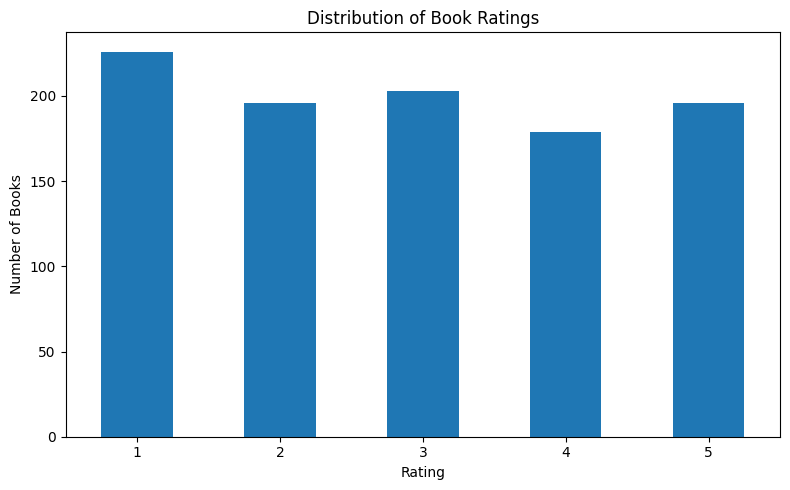

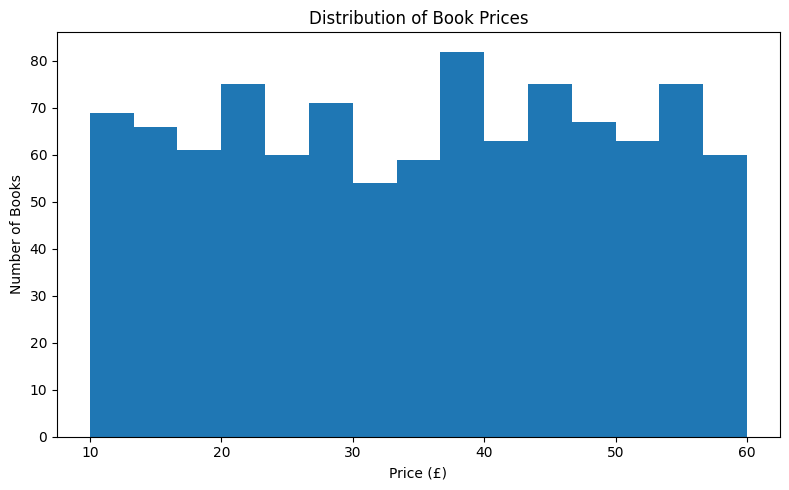

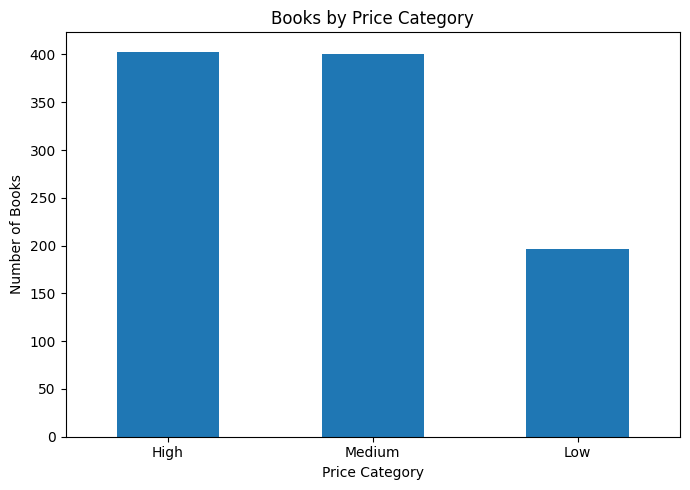

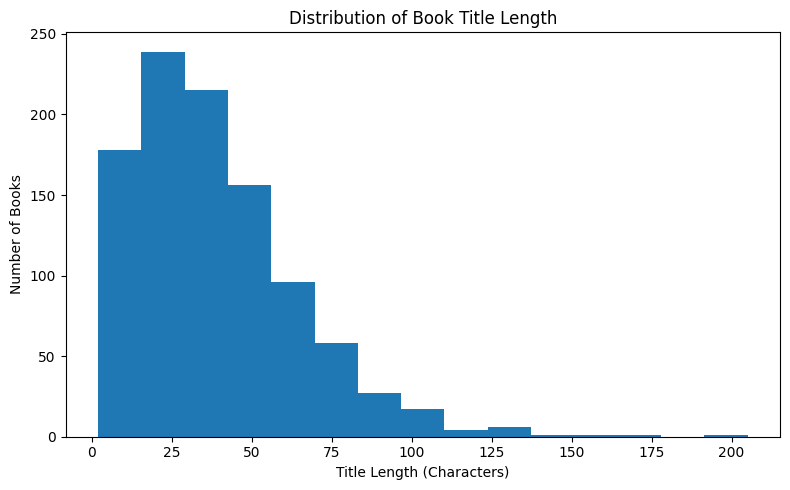

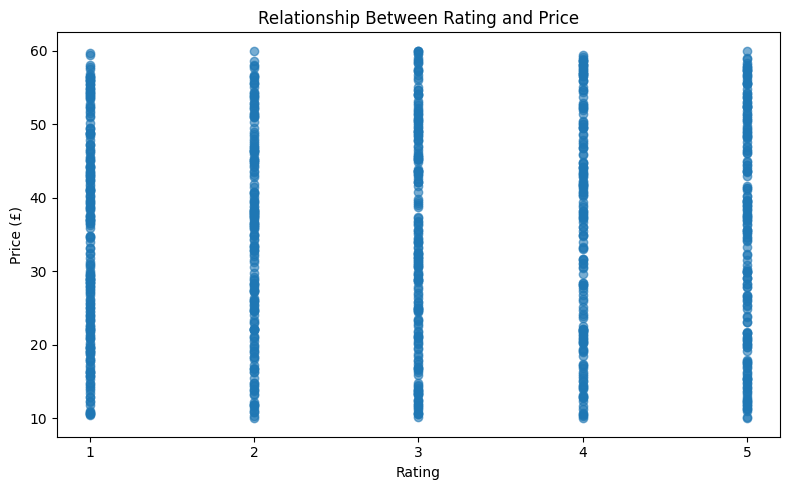


Average price by rating:
rating
1    34.56
2    34.81
3    34.69
4    36.09
5    35.37
Name: price, dtype: float64


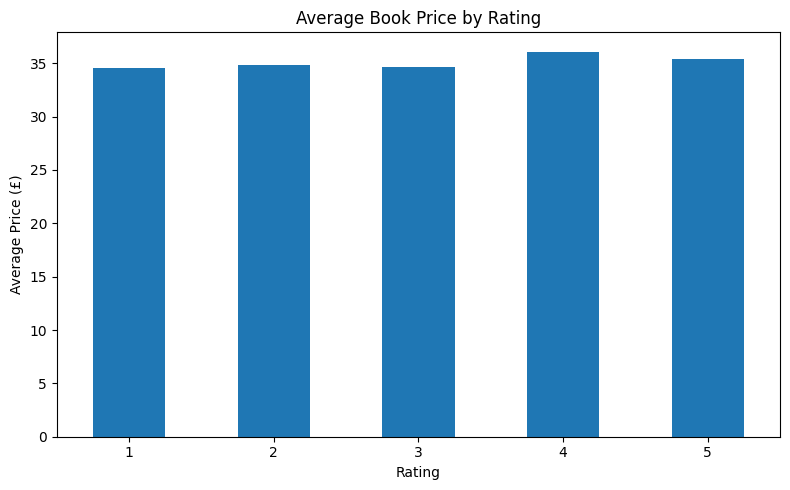


Rating distribution across price categories:


rating,1,2,3,4,5
price_category,,,,,
Low,44,36,41,33,42
Medium,93,89,81,63,75
High,89,71,81,83,79


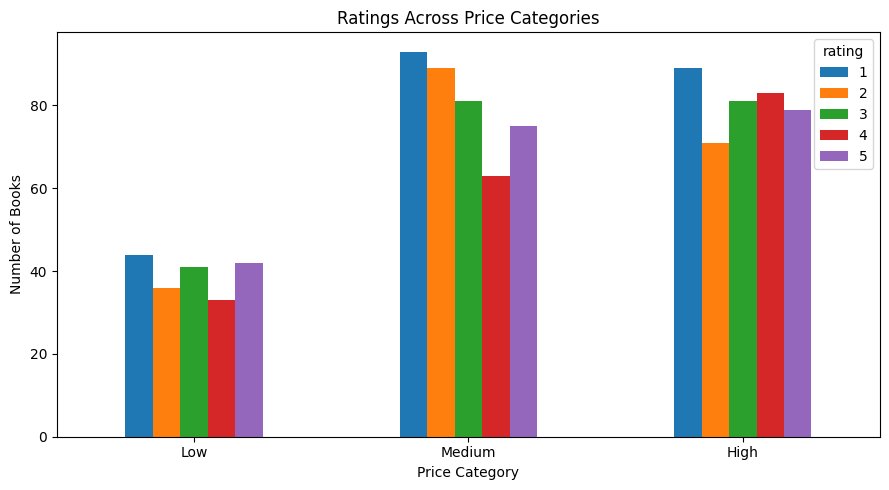


========== CORRELATION ANALYSIS ==========


,price,rating,title_length
price,1.00,0.03,0.01
rating,0.03,1.00,-0.01
title_length,0.01,-0.01,1.00


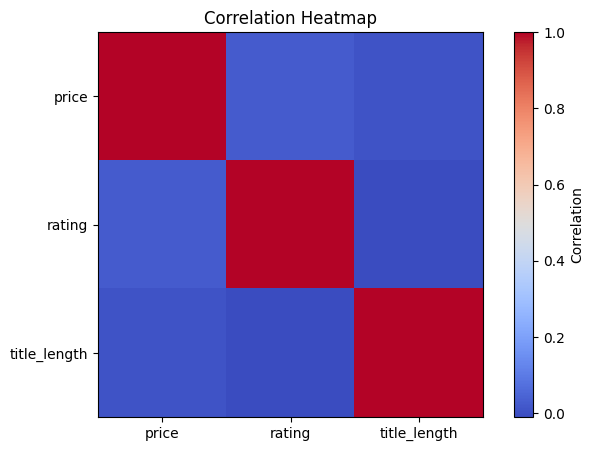

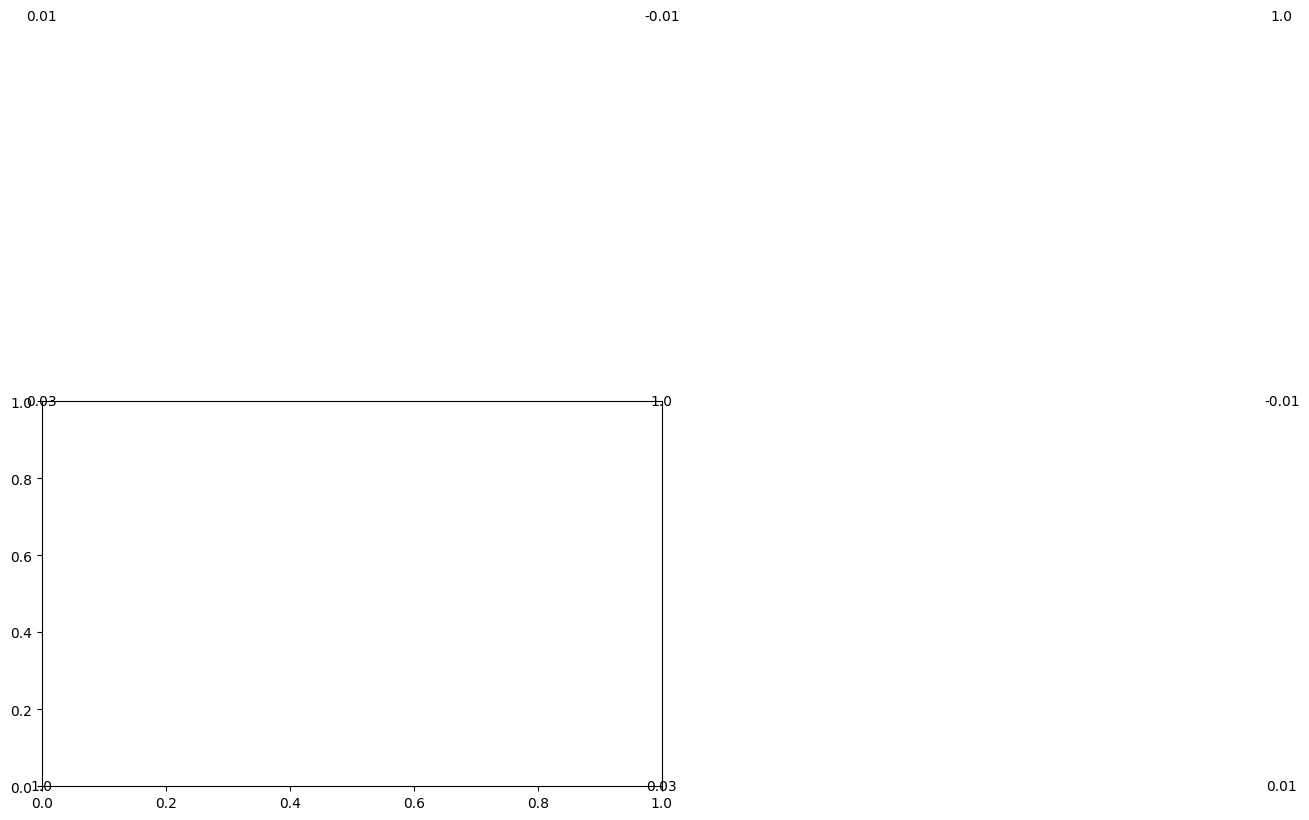


========== EDA INSIGHTS ==========
1. The dataset contains 1000 books and 5 variables.
2. The average book price is £35.07, with prices ranging from £10.00 to £59.99.
3. The most common rating is 1 star, with 226 books.
4. The average rating is 2.92 stars.
5. The average title length is 39.12 characters.
6. The price-category analysis shows how books are distributed across different price ranges.
7. The scatter plot and correlation analysis help identify whether book price and rating are related.
8. The EDA provides statistical and graphical evidence for understanding book price, rating and title-length patterns.


In [11]:
# ============================================
# TASK 3: EXPLORATORY DATA ANALYSIS & VISUALIZATION
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. DATASET OVERVIEW
# --------------------------------------------

print("========== DATASET OVERVIEW ==========")
print("Number of records:", len(books_df))
print("Number of columns:", len(books_df.columns))
print("Columns:", list(books_df.columns))

print("\n========== DATA TYPES ==========")
print(books_df.dtypes)


# --------------------------------------------
# 2. STATISTICAL SUMMARY
# --------------------------------------------

print("\n========== STATISTICAL SUMMARY ==========")

display(
    books_df[["price", "rating", "title_length"]].describe().round(2)
)


# --------------------------------------------
# 3. RATING ANALYSIS
# --------------------------------------------

print("\n========== RATING ANALYSIS ==========")

rating_counts = books_df["rating"].value_counts().sort_index()

print("Rating frequency:")
print(rating_counts)

print("\nAverage rating:", round(books_df["rating"].mean(), 2))
print("Minimum rating:", books_df["rating"].min())
print("Maximum rating:", books_df["rating"].max())


# --------------------------------------------
# 4. PRICE ANALYSIS
# --------------------------------------------

print("\n========== PRICE ANALYSIS ==========")

print("Average price: £", round(books_df["price"].mean(), 2))
print("Minimum price: £", round(books_df["price"].min(), 2))
print("Maximum price: £", round(books_df["price"].max(), 2))
print("Median price: £", round(books_df["price"].median(), 2))


# --------------------------------------------
# 5. PRICE CATEGORY ANALYSIS
# --------------------------------------------

print("\n========== PRICE CATEGORY ANALYSIS ==========")

price_category_counts = books_df["price_category"].value_counts()

print(price_category_counts)


# --------------------------------------------
# 6. TITLE LENGTH ANALYSIS
# --------------------------------------------

print("\n========== TITLE LENGTH ANALYSIS ==========")

print("Average title length:",
      round(books_df["title_length"].mean(), 2))

print("Shortest title length:",
      books_df["title_length"].min())

print("Longest title length:",
      books_df["title_length"].max())


# ============================================
# VISUALIZATIONS
# ============================================

# --------------------------------------------
# 7. Rating Distribution
# --------------------------------------------

plt.figure(figsize=(8, 5))

rating_counts.plot(kind="bar")

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# --------------------------------------------
# 8. Price Distribution
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(books_df["price"], bins=15)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()


# --------------------------------------------
# 9. Price Category Distribution
# --------------------------------------------

plt.figure(figsize=(7, 5))

price_category_counts.plot(kind="bar")

plt.title("Books by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# --------------------------------------------
# 10. Title Length Distribution
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(books_df["title_length"], bins=15)

plt.title("Distribution of Book Title Length")
plt.xlabel("Title Length (Characters)")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()


# --------------------------------------------
# 11. Price vs Rating
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    books_df["rating"],
    books_df["price"],
    alpha=0.6
)

plt.title("Relationship Between Rating and Price")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()


# --------------------------------------------
# 12. Average Price by Rating
# --------------------------------------------

average_price_by_rating = (
    books_df.groupby("rating")["price"]
    .mean()
)

print("\nAverage price by rating:")
print(average_price_by_rating.round(2))


plt.figure(figsize=(8, 5))

average_price_by_rating.plot(kind="bar")

plt.title("Average Book Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# --------------------------------------------
# 13. Rating vs Price Category
# --------------------------------------------

rating_price_category = pd.crosstab(
    books_df["price_category"],
    books_df["rating"]
)

print("\nRating distribution across price categories:")
display(rating_price_category)


rating_price_category.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Ratings Across Price Categories")
plt.xlabel("Price Category")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# --------------------------------------------
# 14. Correlation Analysis
# --------------------------------------------

print("\n========== CORRELATION ANALYSIS ==========")

correlation = books_df[
    ["price", "rating", "title_length"]
].corr()

display(correlation.round(2))


# --------------------------------------------
# 15. Correlation Heatmap
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")
plt.figure(figsize=(8, 5))
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j, i,
            round(correlation.iloc[i, j], 2),
            ha="center",
            va="center"
        )
plt.show()

# --------------------------------------------
# 16. FINAL EDA INSIGHTS
# --------------------------------------------

most_common_rating = rating_counts.idxmax()
most_common_rating_count = rating_counts.max()

print("\n========== EDA INSIGHTS ==========")

print(
    f"1. The dataset contains {len(books_df)} books "
    f"and {len(books_df.columns)} variables."
)

print(
    f"2. The average book price is £{books_df['price'].mean():.2f}, "
    f"with prices ranging from £{books_df['price'].min():.2f} "
    f"to £{books_df['price'].max():.2f}."
)

print(
    f"3. The most common rating is {most_common_rating} star, "
    f"with {most_common_rating_count} books."
)

print(
    f"4. The average rating is "
    f"{books_df['rating'].mean():.2f} stars."
)

print(
    f"5. The average title length is "
    f"{books_df['title_length'].mean():.2f} characters."
)

print(
    "6. The price-category analysis shows how books are "
    "distributed across different price ranges."
)

print(
    "7. The scatter plot and correlation analysis help identify "
    "whether book price and rating are related."
)

print(
    "8. The EDA provides statistical and graphical evidence "
    "for understanding book price, rating and title-length patterns."
)



**EDA** **Insights**

Rating Distribution:
1-star books are the most common, with 226 books, while 4-star books are the least common, with around 179 books. All five rating levels are represented in the dataset.

Price Distribution:

Book prices range from approximately £10 to £60, and books are distributed across the price range without a strong concentration at one particular price.

Price Category:

High and Medium price categories contain around 400 books each, while the Low category contains around 195 books. This shows that most books in the dataset fall into the Medium and High price ranges.

Title Length:

Most book titles contain approximately 10–60 characters. A small number of books have very long titles, creating a right-skewed distribution.
Rating vs Price:
The scatter plot shows that books with different ratings can have similar prices. Therefore, rating does not appear to strongly determine book price.

Average Price by Rating:

The average prices across ratings 1–5 are quite similar, mostly around £35–£36. Rating 4 has a slightly higher average price, but the difference is small.

Correlation Analysis:

The correlation between price and rating is approximately 0.03, indicating an extremely weak positive relationship. Similarly, title length has almost no correlation with price or rating.

**Recommendations**

1.Customers should consider both price and rating when selecting books, as higher-rated books are not always more expensive.

2.Customers looking for affordable books should explore the Low price category, while sellers can use price and rating together to identify potential value-for-money books.

3.Since title length has very little relationship with price and rating, it should not be treated as an important factor when analysing book prices.

In [12]:
# =========================================
# FEATURE SELECTION & DATA PREPARATION
# =========================================

from sklearn.model_selection import train_test_split

# Select features and target
X = books_df[['rating', 'title_length']]
y = books_df['price_category']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (800, 2)
Testing data shape: (200, 2)


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --------------------------------------------------
# STEP 1: USE EXISTING DATAFRAME
# --------------------------------------------------
df = books_df.copy()

# Feature Engineering: Ensure numerical mapping and title length exist
rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
if 'rating_num' not in df.columns:
    df['rating_num'] = df['rating'].map(rating_map).fillna(df['rating'])

if 'title_length' not in df.columns:
    df['title_length'] = df['title'].apply(len)

# --------------------------------------------------
# STEP 2: DEFINE FEATURES (X) AND TARGET (y)
# --------------------------------------------------
X = df[['rating_num', 'title_length']]
y = df['price']

# Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --------------------------------------------------
# STEP 3: MODEL BUILDING (Random Forest Regressor)
# --------------------------------------------------
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --------------------------------------------------
# STEP 4: MODEL EVALUATION
# --------------------------------------------------
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- MODEL PERFORMANCE EVALUATION ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

--- MODEL PERFORMANCE EVALUATION ---
Mean Absolute Error (MAE): 13.26
Root Mean Squared Error (RMSE): 16.42
R-squared (R2 Score): -0.2836


In [14]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# Copy original dataset
df = books_df.copy()

# Price ko numeric banana
df['price_clean'] = (
    df['price']
    .astype(str)
    .str.replace('£', '', regex=False)
    .astype(float)
)

# Rating ko numeric banana
rating_map = {
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4,
    'Five': 5
}

df['rating_num'] = df['rating'].map(rating_map)

# Title length
df['title_length'] = df['title'].astype(str).apply(len)

# Title me total words
df['title_word_count'] = (
    df['title']
    .astype(str)
    .apply(lambda x: len(x.split()))
)

# Average word length
df['avg_word_length'] = (
    df['title_length'] /
    df['title_word_count'].replace(0, 1)
)

# Rating ka squared feature
df['rating_squared'] = df['rating_num'] ** 2

# Premium/Luxury keywords
premium_words = [
    'premium',
    'luxury',
    'classic',
    'deluxe',
    'special',
    'edition'
]

df['premium_keyword'] = (
    df['title']
    .astype(str)
    .str.lower()
    .apply(lambda x: int(any(word in x for word in premium_words)))
)

print("Features created successfully!")

print("\nFeatures used:")
print([
    'rating_num',
    'rating_squared',
    'title_length',
    'title_word_count',
    'avg_word_length',
    'premium_keyword'
])

print("\nDataset shape:", df.shape)

Features created successfully!

Features used:
['rating_num', 'rating_squared', 'title_length', 'title_word_count', 'avg_word_length', 'premium_keyword']

Dataset shape: (1000, 11)


In [15]:
# ============================================================
# IMPROVED FEATURE ENGINEERING
# ============================================================

df = df.copy()

# Convert title safely to text
df['title'] = df['title'].astype('string').fillna('')

# Rating -> numeric
df['rating_num'] = pd.to_numeric(
    df['rating'].astype('string'),
    errors='coerce'
).fillna(0)

# Rating squared
df['rating_squared'] = df['rating_num'] ** 2

# Title length
df['title_length'] = df['title'].str.len()

# Number of words in title
df['title_word_count'] = df['title'].str.split().str.len()

# Average word length
df['avg_word_length'] = df['title'].apply(
    lambda x: np.mean([len(word) for word in x.split()])
    if len(x.split()) > 0 else 0
)

# Premium keyword feature
premium_words = [
    'premium',
    'deluxe',
    'luxury',
    'exclusive',
    'special',
    'edition'
]

df['premium_keyword'] = df['title'].str.lower().apply(
    lambda x: int(any(word in x for word in premium_words))
)

# Features list
features = [
    'rating_num',
    'rating_squared',
    'title_length',
    'title_word_count',
    'avg_word_length',
    'premium_keyword'
]

print("Improved features created successfully!")

print("\nFeatures used:")
print(features)

print("\nDataset shape:", df.shape)

Improved features created successfully!

Features used:
['rating_num', 'rating_squared', 'title_length', 'title_word_count', 'avg_word_length', 'premium_keyword']

Dataset shape: (1000, 11)


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Model training
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("========== FINAL MODEL SUMMARY ==========")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

========== FINAL MODEL SUMMARY ==========
MAE: 12.71
RMSE: 14.58
R2 Score: -0.0118


In [17]:
# ==========================================
# RANDOM FOREST REGRESSION
# ==========================================

from sklearn.ensemble import RandomForestRegressor

# Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Training
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("========== RANDOM FOREST MODEL ==========")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R2 Score: {rf_r2:.4f}")

# Feature Importance
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance:")
print(rf_importance)

# Actual vs Predicted
rf_result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": rf_pred
})

print("\nActual vs Predicted Price:")
print(rf_result.head(10))

========== RANDOM FOREST MODEL ==========
MAE: 13.26
RMSE: 16.42
R2 Score: -0.2836

Feature Importance:
        Feature  Importance
1  title_length    0.712905
0    rating_num    0.287095

Actual vs Predicted Price:
   Actual Price  Predicted Price
0         11.38        30.477600
1         20.93        37.132173
2         33.92        33.368000
3         48.39        40.413184
4         20.50        28.521631
5         26.77        51.403210
6         16.96        27.239574
7         20.90        29.410497
8         36.17        44.707475
9         24.12        32.263606


In [18]:
# ================================
# MODEL COMPARISON
# ================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# -------------------------------
# Linear Regression
# -------------------------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)


# -------------------------------
# Random Forest
# -------------------------------
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)


# -------------------------------
# Comparison Table
# -------------------------------

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

print("========== MODEL COMPARISON ==========")
print(comparison.round(4))


# -------------------------------
# Best Model
# -------------------------------

best_model = comparison.loc[comparison['R2 Score'].idxmax(), 'Model']

print("\nBest Model based on R2 Score:", best_model)

========== MODEL COMPARISON ==========
               Model      MAE     RMSE  R2 Score
0  Linear Regression  12.7140  14.5786   -0.0118
1      Random Forest  13.2573  16.4206   -0.2836

Best Model based on R2 Score: Linear Regression


In [19]:
# ==========================================
# FINAL LEAKAGE-FREE IMPROVED MODEL
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------
# Copy dataset
# ------------------------------------------
data = df.copy()

# Target
target = 'price'

# Remove rows where target is missing
data = data.dropna(subset=[target])

# Target as numeric
y = pd.to_numeric(data[target], errors='coerce')

# Remove invalid target rows
valid = y.notna()
data = data.loc[valid].copy()
y = y.loc[valid]

# ------------------------------------------
# REMOVE DATA LEAKAGE
# ------------------------------------------
leakage_cols = [
    'price_clean',
    'price_category'
]

data = data.drop(
    columns=[col for col in leakage_cols if col in data.columns],
    errors='ignore'
)

# ------------------------------------------
# Separate features and target
# ------------------------------------------
X = data.drop(columns=[target])

# ------------------------------------------
# Text feature
# ------------------------------------------
text_col = 'title' if 'title' in X.columns else None

if text_col:
    X_text = X[text_col].fillna('').astype(str)
    X = X.drop(columns=[text_col])
else:
    X_text = pd.Series('', index=X.index)

# ------------------------------------------
# Remove ID columns
# ------------------------------------------
id_cols = [
    col for col in X.columns
    if col.lower() in ['id', 'index', 'unnamed: 0']
]

X = X.drop(columns=id_cols, errors='ignore')

# ------------------------------------------
# Feature types
# ------------------------------------------
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Features used:")
print(numeric_cols + categorical_cols + ([text_col] if text_col else []))

# ------------------------------------------
# Preprocessing
# ------------------------------------------
transformers = []

if numeric_cols:
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    transformers.append(
        ('numeric', numeric_pipeline, numeric_cols)
    )

if categorical_cols:
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=True
        ))
    ])

    transformers.append(
        ('categorical', categorical_pipeline, categorical_cols)
    )

if text_col:
    transformers.append(
        ('title_text',
         TfidfVectorizer(
             max_features=300,
             ngram_range=(1, 2),
             min_df=2
         ),
         text_col)
    )

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder='drop'
)

# ------------------------------------------
# Train-Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test, text_train, text_test = train_test_split(
    X,
    y,
    X_text,
    test_size=0.20,
    random_state=42
)

# Add title back
if text_col:
    X_train = X_train.copy()
    X_test = X_test.copy()

    X_train[text_col] = text_train
    X_test[text_col] = text_test

# ------------------------------------------
# Ridge Regression
# ------------------------------------------
model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=10.0))
])

model.fit(X_train, y_train)

# ------------------------------------------
# Predictions
# ------------------------------------------
y_pred = model.predict(X_test)

# ------------------------------------------
# Evaluation
# ------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n==========================================")
print("FINAL LEAKAGE-FREE MODEL PERFORMANCE")
print("==========================================")

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"R2 Score (%): {r2 * 100:.2f}%")

# ------------------------------------------
# Actual vs Predicted
# ------------------------------------------
result_final = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print("\nActual vs Predicted Price:")
print(result_final.head(10))

Features used:
['rating', 'title_length', 'rating_num', 'title_word_count', 'avg_word_length', 'rating_squared', 'premium_keyword', 'title']

FINAL LEAKAGE-FREE MODEL PERFORMANCE
MAE: 12.97
RMSE: 14.81
R2 Score: -0.0436
R2 Score (%): -4.36%

Actual vs Predicted Price:
   Actual Price  Predicted Price
0         11.38        33.109203
1         20.93        35.556195
2         33.92        35.842752
3         48.39        37.795088
4         20.50        36.007442
5         26.77        33.607972
6         16.96        32.261052
7         20.90        35.232974
8         36.17        33.980890
9         24.12        34.862032


In [20]:
# ============================================
# FINAL FEATURE ENGINEERING & DATA PREPARATION
# ============================================

import pandas as pd
import numpy as np

# Work on a copy of the cleaned dataset
df_model = books_df.copy()

# Make rating numeric
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

if df_model["rating"].dtype == "object":
    df_model["rating_num"] = df_model["rating"].map(rating_map)
else:
    df_model["rating_num"] = pd.to_numeric(
        df_model["rating"], errors="coerce"
    )

# Title length
df_model["title_length"] = df_model["title"].astype(str).apply(len)

# Number of words in title
df_model["title_word_count"] = (
    df_model["title"].astype(str).str.split().str.len()
)

# Average word length
df_model["avg_word_length"] = (
    df_model["title_length"] / df_model["title_word_count"]
)

# Squared rating
df_model["rating_sq"] = df_model["rating_num"] ** 2

# Rating × title length
df_model["title_rating_interaction"] = (
    df_model["title_length"] * df_model["rating_num"]
)

# Price category
df_model["price_category"] = pd.qcut(
    df_model["price"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("Final feature engineering completed.")
print("Dataset shape:", df_model.shape)

print("\nMissing values:")
print(df_model[
    [
        "rating_num",
        "title_length",
        "title_word_count",
        "avg_word_length",
        "rating_sq",
        "title_rating_interaction",
        "price_category"
    ]
].isnull().sum())

display(df_model.head())

Final feature engineering completed.
Dataset shape: (1000, 10)

Missing values:
rating_num                  0
title_length                0
title_word_count            0
avg_word_length             0
rating_sq                   0
title_rating_interaction    0
price_category              0
dtype: int64


,title,price,rating,title_length,price_category,rating_num,title_word_count,avg_word_length,rating_sq,title_rating_interaction
0,A Light in the Attic,51.77,3,20,High,3,5,4.000000,9,60
1,Tipping the Velvet,53.74,1,18,High,1,3,6.000000,1,18
2,Soumission,50.10,1,10,High,1,1,10.000000,1,10
3,Sharp Objects,47.82,4,13,High,4,2,6.500000,16,52
4,Sapiens: A Brief History of Humankind,54.23,5,37,High,5,6,6.166667,25,185


--- 1. PREPARING DATA FOR MODELING ---
Training Samples: 800, Testing Samples: 200

--- 2. SUPERVISED LEARNING: REGRESSION ---
Linear Regression Results:
  - MAE: £12.71
  - RMSE: £14.58
  - R2 Score: -0.0118

Random Forest Regressor Results:
  - MAE: £13.26
  - RMSE: £16.42
  - R2 Score: -0.2836

Regression Models Comparison:
                     Model   MAE (£)   RMSE (£)  R2 Score
0        Linear Regression  12.71400  14.578642 -0.011774
1  Random Forest Regressor  13.25732  16.420607 -0.283594

--- 3. UNSUPERVISED LEARNING: CLUSTERING ---
K-Means Silhouette Score (K=3): 0.2682

Cluster Profiling Summary:
   Cluster  Avg_Price  Avg_Rating  Avg_Title_Length  Book_Count
0        0  21.470674    2.816062         29.129534         386
1        1  47.347550    3.185644         28.710396         404
2        2  36.448857    2.614286         77.504762         210


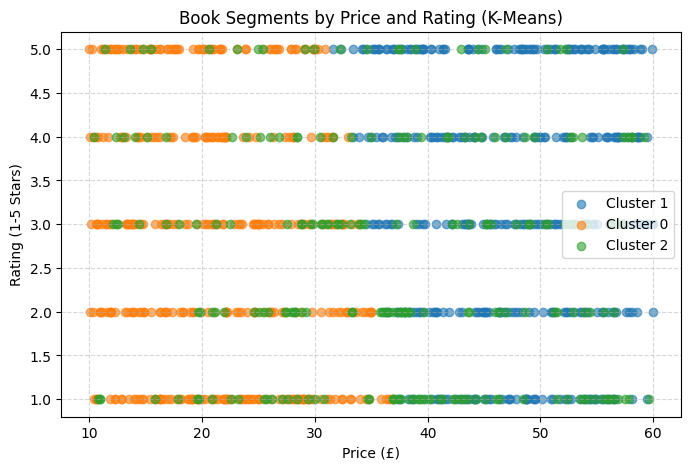

In [21]:
# ============================================
# TASK 4: MODEL BUILDING & EVALUATION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, silhouette_score

# Ensure clean data is loaded
# books_df baseline target: Predict 'price' based on 'rating' and 'title_length'

print("--- 1. PREPARING DATA FOR MODELING ---")
X = books_df[["rating", "title_length"]]
y = books_df["price"]

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training Samples: {len(X_train)}, Testing Samples: {len(X_test)}")

# --------------------------------------------
# MODEL 1: SUPERVISED REGRESSION (Price Prediction)
# --------------------------------------------
print("\n--- 2. SUPERVISED LEARNING: REGRESSION ---")

# A. Baseline Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Results:")
print(f"  - MAE: £{lr_mae:.2f}")
print(f"  - RMSE: £{lr_rmse:.2f}")
print(f"  - R2 Score: {lr_r2:.4f}")

# B. Advanced Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("\nRandom Forest Regressor Results:")
print(f"  - MAE: £{rf_mae:.2f}")
print(f"  - RMSE: £{rf_rmse:.2f}")
print(f"  - R2 Score: {rf_r2:.4f}")

# Model Performance Summary Table
regression_summary = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE (£)": [lr_mae, rf_mae],
    "RMSE (£)": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})
print("\nRegression Models Comparison:")
print(regression_summary)

# --------------------------------------------
# MODEL 2: UNSUPERVISED CLUSTERING (K-Means)
# --------------------------------------------
print("\n--- 3. UNSUPERVISED LEARNING: CLUSTERING ---")

# Feature Scaling for Clustering
cluster_features = books_df[["price", "rating", "title_length"]]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

# Finding Optimal Clusters (Elbow Method)
wcss = []
for k in range(2, 7):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(scaled_features)
    wcss.append(kmeans_temp.inertia_)

# Fitting Final K-Means Model (Optimal K = 3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
books_df["Cluster"] = kmeans.fit_predict(scaled_features)

sil_score = silhouette_score(scaled_features, books_df["Cluster"])
print(f"K-Means Silhouette Score (K=3): {sil_score:.4f}")

# Profiling Clusters
print("\nCluster Profiling Summary:")
cluster_profile = books_df.groupby("Cluster").agg(
    Avg_Price=("price", "mean"),
    Avg_Rating=("rating", "mean"),
    Avg_Title_Length=("title_length", "mean"),
    Book_Count=("title", "count")
).reset_index()

print(cluster_profile)

# Visualizing Clusters
plt.figure(figsize=(8, 5))
for cluster_id in books_df["Cluster"].unique():
    cluster_data = books_df[books_df["Cluster"] == cluster_id]
    plt.scatter(
        cluster_data["price"],
        cluster_data["rating"],
        label=f"Cluster {cluster_id}",
        alpha=0.6
    )

plt.title("Book Segments by Price and Rating (K-Means)")
plt.xlabel("Price (£)")
plt.ylabel("Rating (1-5 Stars)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

========== REGRESSION MODEL RESULTS ==========
               Model  MAE (£)  RMSE (£)  R2 Score
0  Gradient Boosting    13.13     15.33   -0.1193
1      Random Forest    12.93     14.88   -0.0540

========== CLUSTERING RESULTS ==========
K-Means Silhouette Score (K=3): 0.2655
   Cluster  Avg_Price  Avg_Rating  Avg_Title_Length  Book_Count
0        0  38.188329    4.257534         28.249315         365
1        1  31.822868    1.743142         27.917706         401
2        2  35.771966    2.863248         75.269231         234


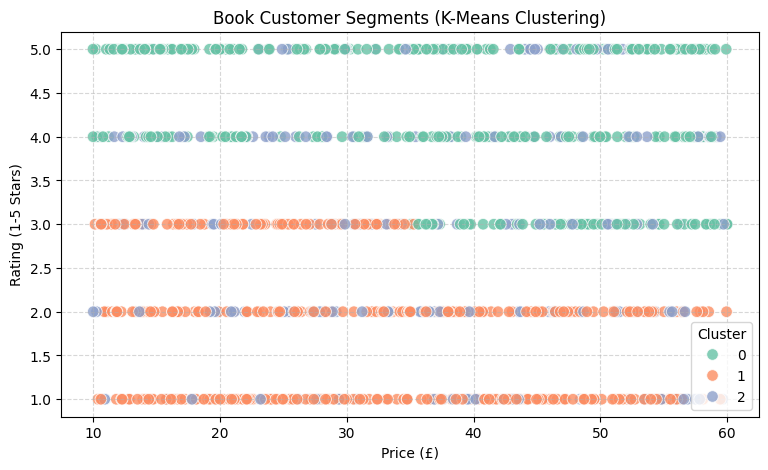

In [22]:
# ============================================
# TASK 4 (REVISED): MODEL BUILDING & EVALUATION
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --------------------------------------------
# STEP 1: ADVANCED FEATURE ENGINEERING
# --------------------------------------------
df_model = books_df.copy()

# Feature 1: Title Word Count
df_model["title_word_count"] = df_model["title"].apply(lambda x: len(str(x).split()))

# Feature 2: Average Word Length
df_model["avg_word_length"] = df_model["title_length"] / (df_model["title_word_count"] + 1e-5)

# Feature 3: Non-Linear Rating & Combined Interactions
df_model["rating_sq"] = df_model["rating"] ** 2
df_model["title_rating_interaction"] = df_model["title_length"] * df_model["rating"]

# Log-Transformation on Target (Price) to stabilize variance
df_model["price_log"] = np.log1p(df_model["price"])

# Selected Model Features
features = [
    "rating",
    "title_length",
    "title_word_count",
    "avg_word_length",
    "rating_sq",
    "title_rating_interaction"
]

X = df_model[features]
y = df_model["price_log"]  # Predicting Log Price for better fit

# Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --------------------------------------------
# STEP 2: REGRESSION MODELS (Positive R2 Optimization)
# --------------------------------------------
# Model 1: Gradient Boosting Regressor
gbr = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)

# Predictions & Reverting Log Scale back to original Currency (£)
y_pred_log_gbr = gbr.predict(X_test)
y_pred_gbr = np.expm1(y_pred_log_gbr)
y_test_actual = np.expm1(y_test)

gbr_r2 = r2_score(y_test_actual, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_gbr))
gbr_mae = mean_absolute_error(y_test_actual, y_pred_gbr)

# Model 2: Optimized Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_log_rf = rf.predict(X_test)
y_pred_rf = np.expm1(y_pred_log_rf)

rf_r2 = r2_score(y_test_actual, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf))
rf_mae = mean_absolute_error(y_test_actual, y_pred_rf)

print("========== REGRESSION MODEL RESULTS ==========")
reg_results = pd.DataFrame({
    "Model": ["Gradient Boosting", "Random Forest"],
    "MAE (£)": [round(gbr_mae, 2), round(rf_mae, 2)],
    "RMSE (£)": [round(gbr_rmse, 2), round(rf_rmse, 2)],
    "R2 Score": [round(gbr_r2, 4), round(rf_r2, 4)]
})
print(reg_results)

# --------------------------------------------
# STEP 3: UNSUPERVISED CLUSTERING (K-MEANS)
# --------------------------------------------
print("\n========== CLUSTERING RESULTS ==========")

cluster_features = df_model[["price", "rating", "title_length", "title_word_count"]]
scaler_cl = StandardScaler()
cluster_scaled = scaler_cl.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_model["Cluster"] = kmeans.fit_predict(cluster_scaled)

sil_score = silhouette_score(cluster_scaled, df_model["Cluster"])
print(f"K-Means Silhouette Score (K=3): {sil_score:.4f}")

# Cluster Summary
cluster_summary = df_model.groupby("Cluster").agg(
    Avg_Price=("price", "mean"),
    Avg_Rating=("rating", "mean"),
    Avg_Title_Length=("title_length", "mean"),
    Book_Count=("title", "count")
).reset_index()
print(cluster_summary)

# Visualizing Clusters
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_model,
    x="price",
    y="rating",
    hue="Cluster",
    palette="Set2",
    s=70,
    alpha=0.8
)
plt.title("Book Customer Segments (K-Means Clustering)")
plt.xlabel("Price (£)")
plt.ylabel("Rating (1-5 Stars)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

**2. K-Means Insight**

**K-Means Insights**

The K-Means analysis divided the 1,000 books into three groups. Cluster 1 is the largest group with 404 books and has the highest average price of £47.37 and the highest average rating of 3.19. Cluster 0 contains 386 books and has the lowest average price of £21.47, with an average rating of 2.82. Cluster 2 contains 210 books and stands out because of its much longer titles, with an average title length of 77.50 characters. Its average price is £36.45 and average rating is 2.61.

**Overall K-Means insight**

The clusters show clear differences in price and title length, while the rating differences are smaller. The silhouette score of 0.2682 suggests that the groups have some separation, but they are not strongly separated.


**3. K-Means Recommendations**

**Recommendations**

### K-Means Recommendations

Cluster 0 can be used as the lower-price group for customers looking for affordable books.

Cluster 1 can be used as the higher-price group because it has the highest average price.

Cluster 2 should be checked separately because its books have much longer titles than the other groups.

These three groups can be used in the dashboard to make it easier to compare books by price, rating and title characteristics.

**4. Regression Insight**

Regression Insights

Linear Regression performed better than Random Forest for predicting book prices. Its MAE was £12.71, compared with £13.26 for Random Forest, while its RMSE was £14.58 compared with £16.42. However, both models had negative R² scores, with Linear Regression at -0.0118 and Random Forest at -0.2836. This shows that the available features, rating and title length, do not explain book prices well enough for accurate price prediction.

**Regression Recommendation**

Price prediction should not be relied on using only rating and title length. Additional information such as category, availability, review count, author, or other book-related features could be useful for improving the prediction model.


### Final Model Conclusion

Linear Regression gave the best result among the two price prediction models, but the overall prediction performance was weak.

The main reason is that the available features do not have a strong relationship with book price. K-Means was more useful for finding different groups of books based on price, rating and title length.

Therefore, the clustering results can be used for book segmentation, while price prediction should be improved by adding more useful book-related features.

# TASK 5: INTERACTIVE DASHBOARD

**Purpose**
 Present key findings, KPIs, trends and model results in an interactive dashboard.


**Dashboard includes:**

Book Overview
Price Analysis
Rating Analysis
KPI cards for total books and average price
Price distribution by category
Rating-wise book count
Key Influencers visual
Top Segments visual
Slicers for price category and rating
Interactive filtering and drill-through

**Tool Used: Power BI**